In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Custom functions
import FockSystem.FockSystem as fst

In [3]:
import numpy as np

In [4]:
import Analysis.transport_tools as tu
from Analysis.systems import kitaev_chain, kramers_chain

In [5]:
from IPython.display import display, Math,Markdown

In [6]:
from itertools import product,combinations,permutations
import cvxpy as cp


## Create all operators

In [69]:
fs = fst.FockSystemBase()
N=2
pos_ops = np.arange(4*N)

def get_combinations(lst, n):
    return list(combinations(lst, n))
    
def generate_combinations(pos_ops):
    all_options = []
    for i in range(1,len(pos_ops)+1):
        combs = get_combinations(pos_ops, i)
        all_options.extend([fs.normal_order_naive(list(c))[0] for c in combs if len(c)%2 == 1])
    return all_options

In [70]:
options = generate_combinations(pos_ops)

In [71]:
options = gamma.oper_list

# Solve simplest system

In [72]:
## Make chain and basis
MU,ECT,CAR = kramers_chain(2)
H_Kitaev = MU + ECT + CAR
basis = fst.FockStates(2)
restr_basis = basis.restrict(Ez_inf =False, U_inf=True)

## Set sweet spot
H_Kitaev[CAR[0]] = 20
H_Kitaev[CAR[1]] = -20
H_Kitaev[ECT] = 20*np.sqrt(2)
H_Kitaev[MU] = 0

## Solve
E,phi = np.linalg.eigh(H_Kitaev[restr_basis].to_array(), UPLO='U')
phi = np.transpose(phi)

In [73]:
def act_oper_on_state(Opers, State):
    states = State.states
    filt_zero = np.where(State.weights != 0)
    relevant_states = np.array(states[filt_zero])
    relevant_phi = State.weights[filt_zero]
    
    result_state = np.zeros(len(states),dtype=complex)

    for operators,oper_weight in zip(Opers.oper_list,Opers.weights):
      
        new_states = relevant_states
        new_signs = np.full(len(relevant_states),1)
        if isinstance(operators,list):
            for op in operators:
                new_states,sign = fs.act_oper(op, new_states)
                new_signs *= sign

        weights = relevant_phi*new_signs*oper_weight

        row_idx=0
        for state,weight in zip(new_states,weights):
            if state>-1 and (state in State.states):
                result_state[State.hashed[state]] += weight
    return fst.FockStates(states = states, weights = result_state)

In [74]:
def build_column_matrix(operator_options, phi_A, basis):
    states = basis.states
    filt_zero = np.where(phi_A != 0)
    relevant_states = np.array(states[filt_zero])
    relevant_phi = phi_A[filt_zero]
    
    column_matrix = np.zeros((len(basis.states), len(operator_options)),dtype=complex)
    
    for col_idx,operators in enumerate(operator_options):
        new_states = relevant_states
        new_signs = np.full(len(relevant_states),1)
        for op in operators:
            new_states,sign = fs.act_oper(op, new_states)
            new_signs *= sign

        weights = relevant_phi*new_signs

        row_idx=0
        for state,weight in zip(new_states,weights):
            if state>-1 and (state in basis.states):
                column_matrix[basis.hashed[state]][col_idx] = weight

    return column_matrix

In [75]:
col_matrix_A = build_column_matrix(options, phi[0], restr_basis)
col_matrix_B = build_column_matrix(options, phi[2], restr_basis)

In [76]:
M_stacked = np.vstack([
    col_matrix_A,   # shape (D, M)
    col_matrix_B    # shape (D, M)
],dtype=complex)           # shape (2D, M)

phi_stacked = np.concatenate([
    phi[2],       # |B⟩
    phi[0]        # |A⟩
],dtype=complex)           # shape (2D,)

In [77]:
result = np.round(np.linalg.lstsq(M_stacked, phi_stacked)[0],5)

In [37]:
filt_zeros = np.where(result != 0)[0]
weights = result[filt_zeros]
opers = [options[i] for i in filt_zeros]

H = fst.OperSequence(opers, weights=list(weights), bypass_parse=True)

odd_state = fst.FockStates(states = restr_basis.states, weights = phi[0])
even_state = fst.FockStates(states = restr_basis.states, weights = phi[2])

display(Markdown(f'Odd state: {odd_state._repr_markdown_()}'))
display(Markdown(f'Even state: {even_state._repr_markdown_()}'))
display(Markdown('$\\gamma$ = ' + f' {H._repr_markdown_()}'))


Odd state:  -0.707|↑,0〉+ 0.707|0,↑〉

Even state:  -0.707|0,0〉-0.5|↑,↓〉+ 0.5|↓,↑〉

$\gamma$ =   $c^{†}_{0,↓}$$c_{0,↓}$$c_{1,↑}$ $-$ $c_{1,↑}$ $-$ 0.707$c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↓}$ $+$ 0.707$c^{†}_{0,↑}$$c_{0,↓}$$c_{1,↑}$ $+$ $c^{†}_{1,↑}$$c^{†}_{0,↑}$$c_{0,↑}$ $-$ $c^{†}_{1,↑}$ $-$ 0.707$c^{†}_{1,↓}$$c^{†}_{0,↑}$$c_{0,↑}$ $+$ 0.707$c^{†}_{1,↑}$$c^{†}_{0,↓}$$c_{0,↑}$

In [38]:
gamma

 $c^{†}_{0,↓}$$c_{0,↓}$$c_{1,↑}$ $+$ $c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↑}$ $-$ $c_{1,↑}$ $-$ 0.707$c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↓}$ $+$ 0.707$c^{†}_{0,↑}$$c_{0,↓}$$c_{1,↑}$ $+$ $c^{†}_{1,↑}$$c^{†}_{0,↓}$$c_{0,↓}$ $+$ $c^{†}_{1,↑}$$c^{†}_{0,↑}$$c_{0,↑}$ $-$ $c^{†}_{1,↑}$ $-$ 0.707$c^{†}_{1,↓}$$c^{†}_{0,↑}$$c_{0,↑}$ $+$ 0.707$c^{†}_{1,↑}$$c^{†}_{0,↓}$$c_{0,↑}$

In [39]:
act_oper_on_state(H, odd_state)

 -0.707|0,0〉-0.5|↑,↓〉+ 0.5|↓,↑〉

In [40]:
act_oper_on_state(H, even_state)

 -0.707|↑,0〉+ 0.707|0,↑〉

## Known solution

In [41]:
c_d_L = fst.OperSequence(0)
c_u_L = fst.OperSequence(2)
c_d_R = fst.OperSequence(4)
c_u_R = fst.OperSequence(6)
n_L_u = c_u_L*(~c_u_L)
n_L = c_d_L*(~c_d_L) + c_u_L*(~c_u_L)
gamma_R_up = -(-n_L+1)*(~c_u_R) - 1/np.sqrt(2)*(n_L_u*(~c_d_R) - c_u_L*(~c_d_L)*(~c_u_R))
gamma = gamma_R_up + (~gamma_R_up)

In [42]:
odd_state = fst.FockStates(states = restr_basis.states, weights = phi[0])

## Adding constraints

In [52]:
fs = fst.FockSystemBase()
N=2
pos_ops = np.arange(4*N)

def get_combinations(lst, n):
    return list(combinations(lst, n))
    
def generate_combinations(pos_ops):
    all_options = []
    for i in range(1,len(pos_ops)+1):
        combs = get_combinations(pos_ops, i)
        all_options.extend([fs.normal_order_naive(list(c))[0] for c in combs if (len(c) %2 == 1)])
    return all_options

options = generate_combinations(pos_ops)
options = gamma.oper_list

In [53]:
## Make chain and basis
MU,ECT,CAR = kramers_chain(2)
H_Kitaev = MU + ECT + CAR
basis = fst.FockStates(2)
restr_basis = basis.restrict(Ez_inf =False, U_inf=True)

## Set sweet spot
H_Kitaev[CAR[0]] = 20
H_Kitaev[CAR[1]] = -20
H_Kitaev[ECT] = 20*np.sqrt(2)
H_Kitaev[MU] = 0

## Solve
E,phi = np.linalg.eigh(H_Kitaev[restr_basis].to_array(), UPLO='U')
phi = np.transpose(phi)

In [54]:
as_sequence = np.array([fst.OperSequence([oper],bypass_parse=True) for oper in options])
pairs,herm_options = [],[]

for idx,seq in enumerate(as_sequence):
    conjugated = ~seq
    conjugated.normal_order()
    
    herm = np.where(as_sequence == conjugated)[0]
    if len(herm)>0:
        pairs.append((idx, int(herm[0]), 1))
        herm_options.append(seq.oper_list[0])
    #herm = np.where(as_sequence == -conjugated)[0]
    #if len(herm)>0:
    #    pairs.append((idx, int(herm[0]), -1))
    #    herm_options.append(seq.oper_list[0])


In [55]:
col_matrix_A = build_column_matrix(options, phi[0], restr_basis)
col_matrix_B = build_column_matrix(options, phi[2], restr_basis)

M_stacked = np.vstack([
    col_matrix_A,   # shape (D, M)
    col_matrix_B    # shape (D, M)
],dtype=complex)           # shape (2D, M)

phi_stacked = np.concatenate([
    phi[2],       # |B⟩
    phi[0]        # |A⟩
],dtype=complex)           # shape (2D,)

In [56]:
A = cp.Variable(len(options))
objective = cp.Minimize(cp.sum_squares(M_stacked @ A - phi_stacked))
constraints = []

for i, j, s in pairs:
    if s == 1:
        constraints.append(A[i] == A[j])
    elif s == -1:
        constraints.append(A[i] == -A[j])

problem = cp.Problem(objective, constraints)
problem.solve()

result = np.round(A.value,4)

In [57]:
filt_zeros = np.where(result != 0)[0]
weights = result[filt_zeros]
opers = [options[i] for i in filt_zeros]

H = fst.OperSequence(opers, weights=list(weights), bypass_parse=True)

odd_state = fst.FockStates(states = restr_basis.states, weights = phi[0])
even_state = fst.FockStates(states = restr_basis.states, weights = phi[2])

display(Markdown(f'Odd state: {odd_state._repr_markdown_()}'))
display(Markdown(f'Even state: {even_state._repr_markdown_()}'))
display(Markdown('$\\gamma$ = ' + f' {H._repr_markdown_()}'))


Odd state:  -0.707|↑,0〉+ 0.707|0,↑〉

Even state:  -0.707|0,0〉-0.5|↑,↓〉+ 0.5|↓,↑〉

$\gamma$ =   $c^{†}_{0,↓}$$c_{0,↓}$$c_{1,↑}$ $+$ $c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↑}$ $-$ $c_{1,↑}$ $-$ 0.707$c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↓}$ $+$ 0.707$c^{†}_{0,↑}$$c_{0,↓}$$c_{1,↑}$ $+$ $c^{†}_{1,↑}$$c^{†}_{0,↓}$$c_{0,↓}$ $+$ $c^{†}_{1,↑}$$c^{†}_{0,↑}$$c_{0,↑}$ $-$ $c^{†}_{1,↑}$ $-$ 0.707$c^{†}_{1,↓}$$c^{†}_{0,↑}$$c_{0,↑}$ $+$ 0.707$c^{†}_{1,↑}$$c^{†}_{0,↓}$$c_{0,↑}$

In [58]:
H

 $c^{†}_{0,↓}$$c_{0,↓}$$c_{1,↑}$ $+$ $c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↑}$ $-$ $c_{1,↑}$ $-$ 0.707$c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↓}$ $+$ 0.707$c^{†}_{0,↑}$$c_{0,↓}$$c_{1,↑}$ $+$ $c^{†}_{1,↑}$$c^{†}_{0,↓}$$c_{0,↓}$ $+$ $c^{†}_{1,↑}$$c^{†}_{0,↑}$$c_{0,↑}$ $-$ $c^{†}_{1,↑}$ $-$ 0.707$c^{†}_{1,↓}$$c^{†}_{0,↑}$$c_{0,↑}$ $+$ 0.707$c^{†}_{1,↑}$$c^{†}_{0,↓}$$c_{0,↑}$

In [59]:
gamma

 $c^{†}_{0,↓}$$c_{0,↓}$$c_{1,↑}$ $+$ $c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↑}$ $-$ $c_{1,↑}$ $-$ 0.707$c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↓}$ $+$ 0.707$c^{†}_{0,↑}$$c_{0,↓}$$c_{1,↑}$ $+$ $c^{†}_{1,↑}$$c^{†}_{0,↓}$$c_{0,↓}$ $+$ $c^{†}_{1,↑}$$c^{†}_{0,↑}$$c_{0,↑}$ $-$ $c^{†}_{1,↑}$ $-$ 0.707$c^{†}_{1,↓}$$c^{†}_{0,↑}$$c_{0,↑}$ $+$ 0.707$c^{†}_{1,↑}$$c^{†}_{0,↓}$$c_{0,↑}$

In [60]:
act_oper_on_state(H, odd_state)

 -0.707|0,0〉-0.5|↑,↓〉+ 0.5|↓,↑〉

In [61]:
act_oper_on_state(gamma, odd_state)

 -0.707|0,0〉-0.5|↑,↓〉+ 0.5|↓,↑〉

In [62]:
act_oper_on_state(H, even_state)

 -0.707|↑,0〉+ 0.707|0,↑〉

In [63]:
act_oper_on_state(gamma, even_state)

 -0.707|↑,0〉+ 0.707|0,↑〉

# Three sites

In [890]:
## Make chain and basis
MU,ECT,CAR = kramers_chain(3)
H_Kitaev = MU + ECT + CAR
basis = fst.FockStates(3)
restr_basis = basis.restrict(Ez_inf =False, U_inf=True)

## Set sweet spot
H_Kitaev[CAR[0]] = 20
H_Kitaev[CAR[1]] = -20
H_Kitaev[CAR[2]] = -20
H_Kitaev[CAR[3]] = 20

H_Kitaev[ECT] = 20*np.sqrt(2)
H_Kitaev[MU] = 0

## Solve
E,phi = np.linalg.eigh(H_Kitaev[restr_basis].to_array(), UPLO='U')
phi = np.transpose(phi)

In [891]:
even_basis = basis.restrict('even',Ez_inf=False,U_inf=True)
odd_basis = basis.restrict('odd',Ez_inf=False,U_inf=True)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:03<00:00, 25.26it/s]


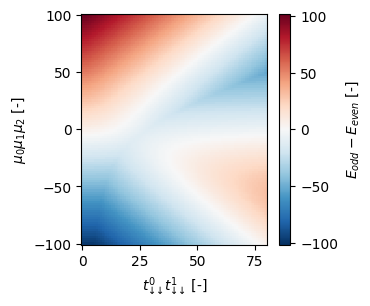

In [892]:
mu_range = np.linspace(-100,100,100)
t_range = np.linspace(0,80,100)

## Loop over range and get array, pass to linalg for eigenvalues
result = tu.phase_diagram(H_Kitaev,odd_basis,even_basis, ECT, t_range, MU, mu_range)

fig,ax = plt.subplots(ncols=1, figsize = (3,3))
result['E'].plot()

## Solve threesites

In [982]:
fst.OperSequence(4)

 $c^{†}_{1,↓}$

In [983]:
fst.OperSequence(5)

 $c_{1,↓}$

In [1032]:
fs = fst.FockSystemBase()
N=3
pos_ops = np.arange(N*4)
pos_ops = [0,1,2,3,4,5,6,7,8,9]
pos_ops = [0,1,2,3,6,7,8,9,10,11]
pos_ops = [0,1,2,3,4,5,8,9,10,11]

def get_combinations(lst, n):
    return list(combinations(lst, n))
    
def generate_combinations(pos_ops):
    all_options = []
    for i in range(1,len(pos_ops)+1):
        combs = get_combinations(pos_ops, i)
        all_options.extend([fs.normal_order_naive(list(c))[0] for c in combs if (len(c) %2 == 1)])
    return all_options

options = generate_combinations(pos_ops)

In [1043]:
## Make chain and basis
MU,ECT,CAR = kramers_chain(3)
H_Kitaev = MU + ECT + CAR
basis = fst.FockStates(3)
restr_basis = basis.restrict(Ez_inf =False, U_inf=True)
phase = np.pi
## Set sweet spot
H_Kitaev[CAR[0]] = 20
H_Kitaev[CAR[1]] = -20
H_Kitaev[CAR[2]] = -20#20*np.exp(-1j*phase)
H_Kitaev[CAR[3]] = 20#*np.exp(-1j*phase)

H_Kitaev[ECT] = 20/np.sqrt(2)#20*np.sqrt(-1/(2*np.cos(phase)))
H_Kitaev[MU] = 0


## Solve
E,phi = np.linalg.eigh(H_Kitaev[restr_basis].to_array(), UPLO='U')
phi = np.transpose(phi)

In [1054]:
fst.FockStates(states= restr_basis.states, weights = phi[2])

 -0.707|0,0,0〉-0.354|↑,↓,0〉+ 0.354|↓,↑,0〉+ 0.354|0,↑,↓〉-0.354|0,↓,↑〉

In [1045]:
as_sequence = np.array([fst.OperSequence([oper],bypass_parse=True) for oper in options])
constraints_three_sites = []
for idx,seq in enumerate(as_sequence):
    conjugated = ~seq
    conjugated.normal_order()
    
    herm = np.where(as_sequence == conjugated)[0]
    if len(herm)>0:
        pairs.append((idx, int(herm[0]), 1))

    herm = np.where(as_sequence == -conjugated)[0]
    if len(herm)>0:
        constraints_three_sites.append((idx, int(herm[0]), -1))


In [1055]:
even_phi =  np.round(phi[0],5)
odd_phi =   np.round(phi[2],5)

col_matrix_A = build_column_matrix(options,even_phi, restr_basis)
col_matrix_B = build_column_matrix(options, odd_phi, restr_basis)

M_stacked = np.vstack([
    col_matrix_A,   # shape (D, M)
    col_matrix_B    # shape (D, M)
],dtype=complex)           # shape (2D, M)

phi_stacked = np.concatenate([
    odd_phi,       # |B⟩
    even_phi       # |A⟩
],dtype=complex)           # shape (2D,)

In [1056]:
A = cp.Variable(len(options),complex=True)
objective = cp.Minimize(cp.sum_squares(M_stacked @ A - phi_stacked))
constraints = []

for i, j, s in constraints_three_sites:
    if s == 1:
        constraints.append(A[i] == cp.conj(A[j]))
    elif s == -1:
        constraints.append(A[i] == -cp.conj(A[j]))

problem = cp.Problem(objective, constraints)
problem.solve()

result = np.round(A.value,4)

In [1057]:
filt_zeros = np.where(result != 0)[0]
weights = result[filt_zeros]
opers = [options[i] for i in filt_zeros]

H = fst.OperSequence(opers, weights=list(weights), bypass_parse=True)

odd_state = fst.FockStates(states = restr_basis.states, weights = odd_phi)
even_state = fst.FockStates(states = restr_basis.states, weights = even_phi)

display(Markdown(f'Odd state: {odd_state._repr_markdown_()}'))
display(Markdown(f'Even state: {even_state._repr_markdown_()}'))
display(Markdown('$\\gamma$ = ' + f' {H._repr_markdown_()}'))


Odd state:  -0.707|0,0,0〉-0.354|↑,↓,0〉+ 0.354|↓,↑,0〉+ 0.354|0,↑,↓〉-0.354|0,↓,↑〉

Even state:  -0.5|↓,0,0〉+ 0.354|0,↓,0〉-0.5|0,0,↓〉-0.25|↑,↓,↓〉+ 0.5|↓,↑,↓〉-0.25|↓,↓,↑〉

$\gamma$ =   0.625$c^{†}_{0,↓}$ $+$ 0.625$c_{0,↓}$ $-$ 0.067$c^{†}_{0,↑}$ $-$ 0.292$c_{0,↑}$ $-$ 0.175$c^{†}_{1,↓}$ $-$ 0.176$c_{1,↓}$ $+$ 0.625$c^{†}_{2,↓}$ $+$ 0.625$c_{2,↓}$ $+$ 0.067$c^{†}_{2,↑}$ $+$ 0.292$c_{2,↑}$ $+$ 0.008$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c_{0,↓}$ $-$ 0.008$c^{†}_{0,↓}$$c_{0,↓}$$c_{1,↓}$ $-$ 0.082$c^{†}_{0,↓}$$c^{†}_{2,↓}$$c_{0,↓}$ $+$ 0.082$c^{†}_{0,↓}$$c_{0,↓}$$c_{2,↓}$ $+$ 0.029$c^{†}_{0,↓}$$c^{†}_{2,↑}$$c_{0,↓}$ $-$ 0.029$c^{†}_{0,↓}$$c_{0,↓}$$c_{2,↑}$ $-$ 0.082$c^{†}_{0,↓}$$c_{0,↑}$$c_{1,↓}$ $+$ 0.038$c^{†}_{0,↓}$$c_{0,↑}$$c_{2,↓}$ $-$ 0.007$c^{†}_{0,↓}$$c^{†}_{2,↑}$$c_{0,↑}$ $+$ 0.001$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c_{1,↓}$ $+$ 0.009$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c_{2,↓}$ $+$ 0.04$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c^{†}_{2,↑}$ $+$ 0.009$c^{†}_{0,↓}$$c_{1,↓}$$c_{2,↓}$ $+$ 0.0$c^{†}_{0,↓}$$c^{†}_{2,↑}$$c_{1,↓}$ $-$ 0.082$c^{†}_{0,↓}$$c_{1,↓}$$c_{2,↑}$ $+$ 0.082$c^{†}_{0,↓}$$c^{†}_{2,↓}$$c_{2,↓}$ $-$ 0.038$c^{†}_{0,↓}$$c^{†}_{2,↑}$$c_{2,↓}$ $+$ 0.007$c^{†}_{0,↓}$$c^{†}_{2,↑}$$c_{2,↑}$ $+$ 0.082$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{0,↓}$ $-$ 0.038$c^{†}_{0,↑}$$c^{†}_{2,↓}$$c_{0,↓}$ $+$ 0.007$c^{†}_{0,↑}$$c_{0,↓}$$c_{2,↑}$ $-$ 0.001$c^{†}_{1,↓}$$c_{0,↓}$$c_{1,↓}$ $-$ 0.009$c^{†}_{1,↓}$$c^{†}_{2,↓}$$c_{0,↓}$ $+$ 0.082$c^{†}_{1,↓}$$c^{†}_{2,↑}$$c_{0,↓}$ $-$ 0.0$c^{†}_{1,↓}$$c_{0,↓}$$c_{2,↑}$ $-$ 0.009$c^{†}_{2,↓}$$c_{0,↓}$$c_{1,↓}$ $-$ 0.04$c_{0,↓}$$c_{1,↓}$$c_{2,↑}$ $-$ 0.082$c^{†}_{2,↓}$$c_{0,↓}$$c_{2,↓}$ $+$ 0.038$c^{†}_{2,↓}$$c_{0,↓}$$c_{2,↑}$ $-$ 0.007$c^{†}_{2,↑}$$c_{0,↓}$$c_{2,↑}$ $-$ 0.021$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{0,↑}$ $+$ 0.021$c^{†}_{0,↑}$$c_{0,↑}$$c_{1,↓}$ $-$ 0.007$c^{†}_{0,↑}$$c^{†}_{2,↓}$$c_{0,↑}$ $+$ 0.007$c^{†}_{0,↑}$$c_{0,↑}$$c_{2,↓}$ $-$ 0.033$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{1,↓}$ $+$ 0.04$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c^{†}_{2,↓}$ $+$ 0.082$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{2,↓}$ $+$ 0.021$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{2,↑}$ $+$ 0.0$c^{†}_{0,↑}$$c^{†}_{2,↓}$$c_{1,↓}$ $+$ 0.021$c^{†}_{0,↑}$$c_{1,↓}$$c_{2,↑}$ $+$ 0.029$c^{†}_{0,↑}$$c^{†}_{2,↓}$$c_{2,↓}$ $+$ 0.007$c^{†}_{0,↑}$$c^{†}_{2,↓}$$c_{2,↑}$ $+$ 0.033$c^{†}_{1,↓}$$c_{0,↑}$$c_{1,↓}$ $-$ 0.0$c^{†}_{1,↓}$$c_{0,↑}$$c_{2,↓}$ $-$ 0.021$c^{†}_{1,↓}$$c^{†}_{2,↑}$$c_{0,↑}$ $-$ 0.082$c^{†}_{2,↓}$$c_{0,↑}$$c_{1,↓}$ $-$ 0.04$c_{0,↑}$$c_{1,↓}$$c_{2,↓}$ $-$ 0.021$c^{†}_{2,↑}$$c_{0,↑}$$c_{1,↓}$ $-$ 0.029$c^{†}_{2,↓}$$c_{0,↑}$$c_{2,↓}$ $-$ 0.007$c^{†}_{2,↑}$$c_{0,↑}$$c_{2,↓}$ $-$ 0.001$c^{†}_{1,↓}$$c^{†}_{2,↓}$$c_{1,↓}$ $+$ 0.001$c^{†}_{1,↓}$$c_{1,↓}$$c_{2,↓}$ $-$ 0.033$c^{†}_{1,↓}$$c^{†}_{2,↑}$$c_{1,↓}$ $+$ 0.033$c^{†}_{1,↓}$$c_{1,↓}$$c_{2,↑}$ $-$ 0.008$c^{†}_{1,↓}$$c^{†}_{2,↓}$$c_{2,↓}$ $+$ 0.082$c^{†}_{1,↓}$$c^{†}_{2,↑}$$c_{2,↓}$ $+$ 0.021$c^{†}_{1,↓}$$c^{†}_{2,↑}$$c_{2,↑}$ $+$ 0.008$c^{†}_{2,↓}$$c_{1,↓}$$c_{2,↓}$ $-$ 0.082$c^{†}_{2,↓}$$c_{1,↓}$$c_{2,↑}$ $-$ 0.021$c^{†}_{2,↑}$$c_{1,↓}$$c_{2,↑}$ $-$ 0.083$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c_{0,↓}$$c_{1,↓}$$c_{2,↑}$ $+$ 0.005$c^{†}_{0,↓}$$c^{†}_{2,↑}$$c_{0,↓}$$c_{1,↓}$$c_{2,↑}$ $-$ 0.083$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c_{0,↑}$$c_{1,↓}$$c_{2,↓}$ $+$ 0.006$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c^{†}_{2,↑}$$c_{0,↑}$$c_{1,↓}$ $+$ 0.005$c^{†}_{0,↓}$$c^{†}_{2,↑}$$c_{0,↑}$$c_{1,↓}$$c_{2,↓}$ $+$ 0.006$c^{†}_{0,↓}$$c^{†}_{1,↓}$$c^{†}_{2,↑}$$c_{1,↓}$$c_{2,↑}$ $-$ 0.152$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{0,↓}$$c_{1,↓}$$c_{2,↑}$ $+$ 0.005$c^{†}_{0,↑}$$c^{†}_{2,↓}$$c_{0,↓}$$c_{1,↓}$$c_{2,↑}$ $+$ 0.083$c^{†}_{1,↓}$$c^{†}_{2,↓}$$c_{0,↓}$$c_{1,↓}$$c_{2,↑}$ $-$ 0.152$c^{†}_{1,↓}$$c^{†}_{2,↑}$$c_{0,↓}$$c_{1,↓}$$c_{2,↑}$ $+$ 0.006$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c^{†}_{2,↓}$$c_{0,↑}$$c_{1,↓}$ $-$ 0.152$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c_{0,↑}$$c_{1,↓}$$c_{2,↓}$ $+$ 0.005$c^{†}_{0,↑}$$c^{†}_{2,↓}$$c_{0,↑}$$c_{1,↓}$$c_{2,↓}$ $+$ 0.006$c^{†}_{0,↑}$$c^{†}_{1,↓}$$c^{†}_{2,↓}$$c_{1,↓}$$c_{2,↑}$ $+$ 0.083$c^{†}_{1,↓}$$c^{†}_{2,↓}$$c_{0,↑}$$c_{1,↓}$$c_{2,↓}$ $-$ 0.152$c^{†}_{1,↓}$$c^{†}_{2,↑}$$c_{0,↑}$$c_{1,↓}$$c_{2,↓}$

In [1058]:
even_state

 -0.5|↓,0,0〉+ 0.354|0,↓,0〉-0.5|0,0,↓〉-0.25|↑,↓,↓〉+ 0.5|↓,↑,↓〉-0.25|↓,↓,↑〉

In [1059]:
act_oper_on_state(H, odd_state)

 -0.5|↓,0,0〉+ 0.354|0,↓,0〉-0.5|0,0,↓〉-0.25|↑,↓,↓〉+ 0.5|↓,↑,↓〉-0.25|↓,↓,↑〉

In [1060]:
odd_state

 -0.707|0,0,0〉-0.354|↑,↓,0〉+ 0.354|↓,↑,0〉+ 0.354|0,↑,↓〉-0.354|0,↓,↑〉

In [1061]:
act_oper_on_state(H, even_state)

 -0.707|0,0,0〉-0.354|↑,↓,0〉+ 0.354|↓,↑,0〉+ 0.354|0,↑,↓〉-0.354|0,↓,↑〉

# The very simplest case

In [31]:
## Make chain and basis
N=4
MU,ECT,CAR = kitaev_chain(N)
H_Kitaev = MU + ECT + CAR
basis = fst.FockStates(N)
restr_basis = basis.restrict(Ez_inf =True, U_inf=True)

H_Kitaev[CAR] = 20
H_Kitaev[ECT] = 20
H_Kitaev[MU] = 0


## Solve
E,phi = np.linalg.eigh(H_Kitaev[restr_basis].to_array(), UPLO='U')
phi = np.transpose(phi)

In [32]:
fs = fst.FockSystemBase()
N=1
pos_ops = np.arange(N*4)

def get_combinations(lst, n):
    return list(combinations(lst, n))
    
def generate_combinations(pos_ops):
    all_options = []
    for i in range(1,len(pos_ops)+1):
        combs = get_combinations(pos_ops, i)
        all_options.extend([fs.normal_order_naive(list(c))[0] for c in combs if (len(c) %2 == 1)])
    return all_options

options = generate_combinations(pos_ops)

In [33]:
as_sequence = np.array([fst.OperSequence([oper],bypass_parse=True) for oper in options])
constraints_two_sites = []
for idx,seq in enumerate(as_sequence):
    conjugated = ~seq
    conjugated.normal_order()
    
    herm = np.where(as_sequence == conjugated)[0]
    if len(herm)>0:
        constraints_two_sites.append((idx, int(herm[0]), 1))

    herm = np.where(as_sequence == -conjugated)[0]
    if len(herm)>0:
        constraints_two_sites.append((idx, int(herm[0]), -1))


In [34]:
col_matrix_A = build_column_matrix(options, phi[0]*-1j, restr_basis)
col_matrix_B = build_column_matrix(options, phi[1]*1j, restr_basis)

M_stacked = np.vstack([
    col_matrix_A,   # shape (D, M)
    col_matrix_B    # shape (D, M)
],dtype=complex)           # shape (2D, M)

phi_stacked = np.concatenate([
    phi[1],       # |B⟩
    phi[0]        # |A⟩
],dtype=complex)           # shape (2D,)

In [35]:
A = cp.Variable(len(options),complex=True)
objective = cp.Minimize(cp.sum_squares(M_stacked @ A - phi_stacked))
constraints = []

for i, j, s in constraints_two_sites:
    if s == 1:
        constraints.append(A[i] == cp.conj(A[j]))
    elif s == -1:
        constraints.append(A[i] == -cp.conj(A[j]))

problem = cp.Problem(objective, constraints)
problem.solve()

result = A.value

In [36]:
filt_zeros = np.where(result != 0)[0]
weights = result[filt_zeros]
opers = [options[i] for i in filt_zeros]

H = fst.OperSequence(opers, weights=list(weights), bypass_parse=True)

odd_state = fst.FockStates(states = restr_basis.states, weights = phi[0])
even_state = fst.FockStates(states = restr_basis.states, weights = phi[2])

display(Markdown(f'Odd state: {odd_state._repr_markdown_()}'))
display(Markdown(f'Even state: {even_state._repr_markdown_()}'))
display(Markdown('$\\gamma$ = ' + f' {H._repr_markdown_()}'))


Odd state:  + 0.354|0,0,0,0〉+ 0.354|↓,↓,0,0〉-0.354|↓,0,↓,0〉+ 0.354|0,↓,↓,0〉+ 0.354|↓,0,0,↓〉-0.354|0,↓,0,↓〉+ 0.354|0,0,↓,↓〉+ 0.354|↓,↓,↓,↓〉

Even state:  + 0.359|0,0,0,0〉-0.159|↓,0,0,0〉+ 0.419|0,↓,0,0〉+ 0.226|↓,↓,0,0〉+ 0.054|0,0,↓,0〉+ 0.134|↓,0,↓,0〉+ 0.314|↓,↓,↓,0〉-0.159|0,0,0,↓〉-0.359|↓,0,0,↓〉+ 0.226|0,↓,0,↓〉-0.419|↓,↓,0,↓〉+ 0.134|0,0,↓,↓〉-0.054|↓,0,↓,↓〉+ 0.314|0,↓,↓,↓〉

$\gamma$ =   $-$ 1.0j$c^{†}_{0,↓}$ $+$ 1.0j$c_{0,↓}$

In [649]:
H

 $-$ 1.0j$c^{†}_{0,↓}$ $+$ 1.0j$c_{0,↓}$

In [650]:
~H

 1.0j$c_{0,↓}$ $-$ 1.0j$c^{†}_{0,↓}$